In [4]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [5]:
data = keras.datasets.mnist.load_data()
#data

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
(x_train, y_train), (x_test , y_test) = data

In [7]:
len(x_train)

60000

In [8]:
len(x_test)

10000

In [9]:
x_train.shape

(60000, 28, 28)

In [10]:
x_train[0].shape

(28, 28)

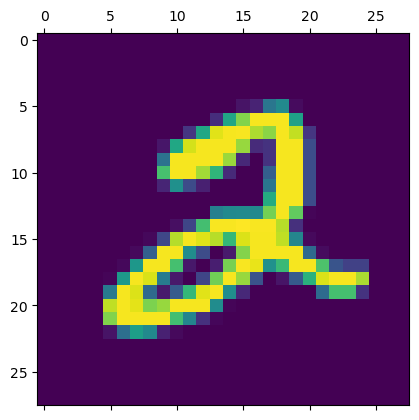

In [11]:
plt.matshow(x_train[5])
plt.show()

In [12]:
y_train[5]

np.uint8(2)

### we scale the value to get optimised result

In [13]:
x_train = x_train / 255
x_test = x_test / 255

### flatten the shape beacause it takes SERIES or id array

In [14]:
x_train_flattened = x_train.reshape(len(x_train), 28*28)
x_test_flattened = x_test.reshape(len(x_test), 28*28)

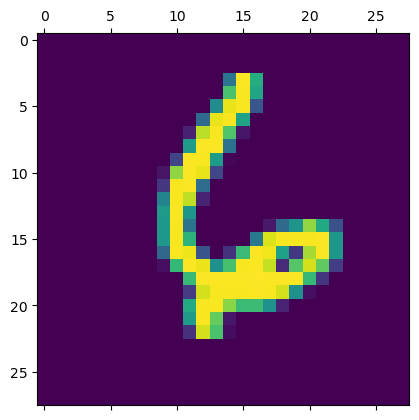

In [21]:
plt.matshow(x_train_flattened[59000].reshape(28,28))

In [22]:
x_train_flattened[:3]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 784))

In [23]:
y_train[:3]

array([5, 0, 4], dtype=uint8)

# neural network without hidden layer

In [24]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation = 'sigmoid')
])

model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

model.fit(x_train_flattened, y_train, epochs = 15)

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8773 - loss: 0.4723
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9151 - loss: 0.3043
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9203 - loss: 0.2836
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9239 - loss: 0.2735
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9257 - loss: 0.2667
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9272 - loss: 0.2621
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9277 - loss: 0.2585
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9292 - loss: 0.2556
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9306 - loss: 0.2529
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9305 - loss: 0.2511
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9316 - loss: 0.2494
Epoch 12/15
1875/1875 

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,552 (92.00 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,702 (61.34 KB)

In [26]:
model.evaluate(x_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9273 - loss: 0.2662


[0.2662118375301361, 0.927299976348877]

### need to flatten the data before predict

In [27]:
y_pred = model.predict(x_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [28]:
y_pred[0]

array([6.3773053e-04, 2.7344578e-09, 4.6010292e-03, 9.8085934e-01,
       1.4121763e-03, 1.3304272e-01, 2.5265445e-09, 9.9991524e-01,
       9.1497824e-02, 7.0570457e-01], dtype=float32)

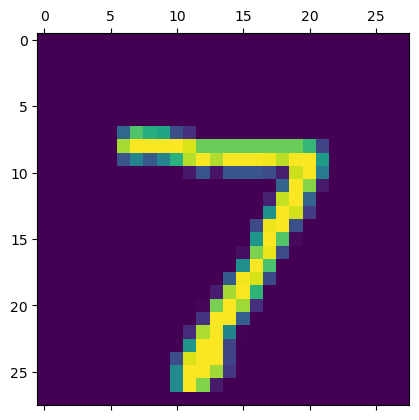

In [29]:
plt.matshow(x_test[0])

In [30]:
np.argmax(y_pred[0])

np.int64(7)

In [31]:
y_predicted_labels = [np.argmax(i) for i in y_pred]

In [32]:
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [33]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 953,    0,    1,    2,    0,    5,   12,    4,    3,    0],
       [   0, 1115,    3,    3,    0,    1,    3,    2,    8,    0],
       [   3,    8,  919,   19,    6,    5,   14,   13,   41,    4],
       [   2,    0,   12,  931,    0,   22,    3,   12,   23,    5],
       [   1,    1,    4,    3,  909,    0,   12,    9,   10,   33],
       [   7,    3,    1,   36,    8,  772,   15,    9,   36,    5],
       [   7,    3,    6,    2,    7,   12,  918,    1,    2,    0],
       [   1,    6,   19,    7,    4,    0,    0,  966,    2,   23],
       [   4,    8,    6,   24,    8,   19,   11,   12,  875,    7],
       [   7,    8,    1,   11,   21,    6,    0,   31,    9,  915]],
      dtype=int32)>

Text(33.22222222222222, 0.5, 'Truth')

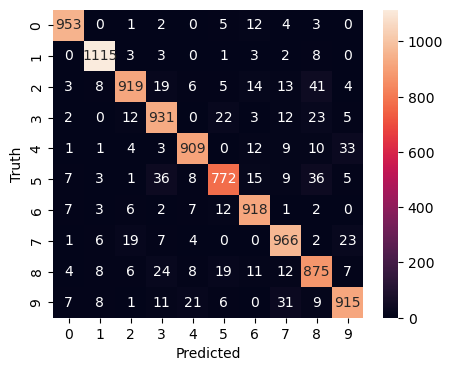

In [34]:
import seaborn as sn
plt.figure(figsize = (5,4))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

# using hidden layer

In [35]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(60, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_flattened, y_train, epochs=5)

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9231 - loss: 0.2585
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9675 - loss: 0.1084
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9761 - loss: 0.0767
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9816 - loss: 0.0602
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9846 - loss: 0.0486


In [36]:
model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0901


[0.09011369943618774, 0.974399983882904]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Text(33.22222222222222, 0.5, 'Truth')

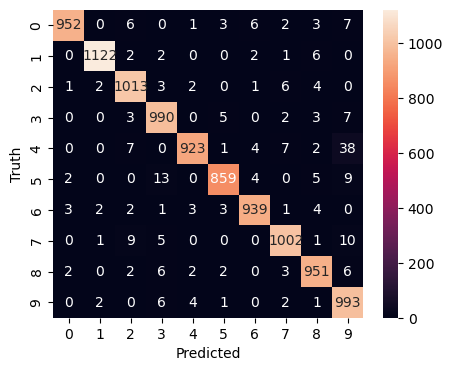

In [37]:
y_predicted = model.predict(x_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)

plt.figure(figsize = (5,4))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

### Using Flatten layer so that we don't have to call .reshape on input dataset

In [27]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9769 - loss: 0.0826


[0.08264536410570145, 0.9768999814987183]

In [26]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10)

C:\Users\SURBHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9240 - loss: 0.2679
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9658 - loss: 0.1199
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9754 - loss: 0.0842
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9803 - loss: 0.0652
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9849 - loss: 0.0499
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9878 - loss: 0.0406
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9899 - loss: 0.0332
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9915 - loss: 0.0269
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9930 - loss: 0.0225
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9943 - loss: 0.0193


In [28]:
from PIL import Image

In [ ]:
img_path = "digit.png"   # Your handwritten digit image

# Open image
img = Image.open(img_path).convert('L')  # Convert to grayscale

# Resize to 28x28
img = img.resize((28, 28))

# Convert to numpy array
img_array = np.array(img)

# Invert colors if background is white and digit is black
# img_array = 255 - img_array

# Normalize
img_array = img_array / 255.0

# Display image
plt.imshow(img_array, cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.show()

In [ ]:
img_input = img_array.reshape(1, 784)

In [ ]:
prediction = model.predict(img_input)

predicted_digit = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Digit:", predicted_digit)
print("Confidence:", confidence)